### Bloc 1 - Analyse exploratoire des données pour modélisation ML
1) Chargement du dataset
2) Fonction informative du dataset et affichage
3) Gestion des doublons
4) Identification et selection des bâtiments qui ne sont pas dédié exclusivement à l'habitation - Exigence technique du client
5) Gestion des valeurs manquantes
6) Filtrage avec les colonnes utilitaires métier dećlarées
7) Recherche des outliers non déclarés
8) Corrélations avec les targets


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import missingno as msno
import seaborn as sns

#### 1) Chargement du dataset à la racine du repertoire data


In [3]:
data = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

#### 2) Fonction informative du dataset et affichage

In [4]:
def info(df, name):
    print(f"Dataset: {name} - {df.shape[0]} rows {df.shape[1]} columns")
    profil = pd.DataFrame({ 
        'columns': df.columns.values,
        'non_null': df.notnull().sum().values,
        'nan': df.isna().sum().values,
        'nan %': (df.isna().sum() / len(df) * 100).values.round(1), 
        'unique':(df.nunique() / len(df) * 100).values.round(1), 
        'types':df.dtypes.values,
        'types_length': df.apply(lambda col:(col.astype(str).str.len().max())).values
    })
    return profil
    

In [5]:
info(data, 'Seattle 2016')

Dataset: Seattle 2016 - 3376 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_length
0,OSEBuildingID,3376,0,0.0,100.0,int64,5.0
1,DataYear,3376,0,0.0,0.0,int64,4.0
2,BuildingType,3376,0,0.0,0.2,str,20.0
3,PrimaryPropertyType,3376,0,0.0,0.7,str,27.0
4,PropertyName,3376,0,0.0,99.6,str,72.0
5,Address,3376,0,0.0,99.3,str,41.0
6,City,3376,0,0.0,0.0,str,7.0
7,State,3376,0,0.0,0.0,str,2.0
8,ZipCode,3360,16,0.5,1.6,float64,7.0
9,TaxParcelIdentificationNumber,3376,0,0.0,96.8,str,25.0


In [6]:
pd.set_option("display.max_columns", None)
display(data.head())

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


#### 3) Gestion des doublons

In [7]:
data.duplicated().sum()

np.int64(0)

Aucun doublons présents.

#### 4) Identification et selection des bâtiments qui ne sont pas dédiés exclusivement à l'habitation

In [8]:
# On identifie ce qu'il y a dans cette colonne afin de selectionner ce qui est pertinent
data['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [9]:
# On instancie un nouveau df avec les batiments que l'on a selectionner dans cette colonne, et on affiche les infos pour constater le résultat
df_NonResidential = data[data['BuildingType'].isin(['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus'])]
info(df_NonResidential, 'Seattle 2016 Non Residential')

Dataset: Seattle 2016 Non Residential - 1668 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_length
0,OSEBuildingID,1668,0,0.0,100.0,int64,5.0
1,DataYear,1668,0,0.0,0.1,int64,4.0
2,BuildingType,1668,0,0.0,0.3,str,18.0
3,PrimaryPropertyType,1668,0,0.0,1.3,str,27.0
4,PropertyName,1668,0,0.0,99.8,str,72.0
5,Address,1668,0,0.0,98.7,str,39.0
6,City,1668,0,0.0,0.1,str,7.0
7,State,1668,0,0.0,0.1,str,2.0
8,ZipCode,1652,16,1.0,2.9,float64,7.0
9,TaxParcelIdentificationNumber,1668,0,0.0,95.1,str,25.0


#### 5) Gestion des valeurs manquantes
On visualise les valeurs manquantes avec msno afin de definir l'approche necessaire.

<Axes: >

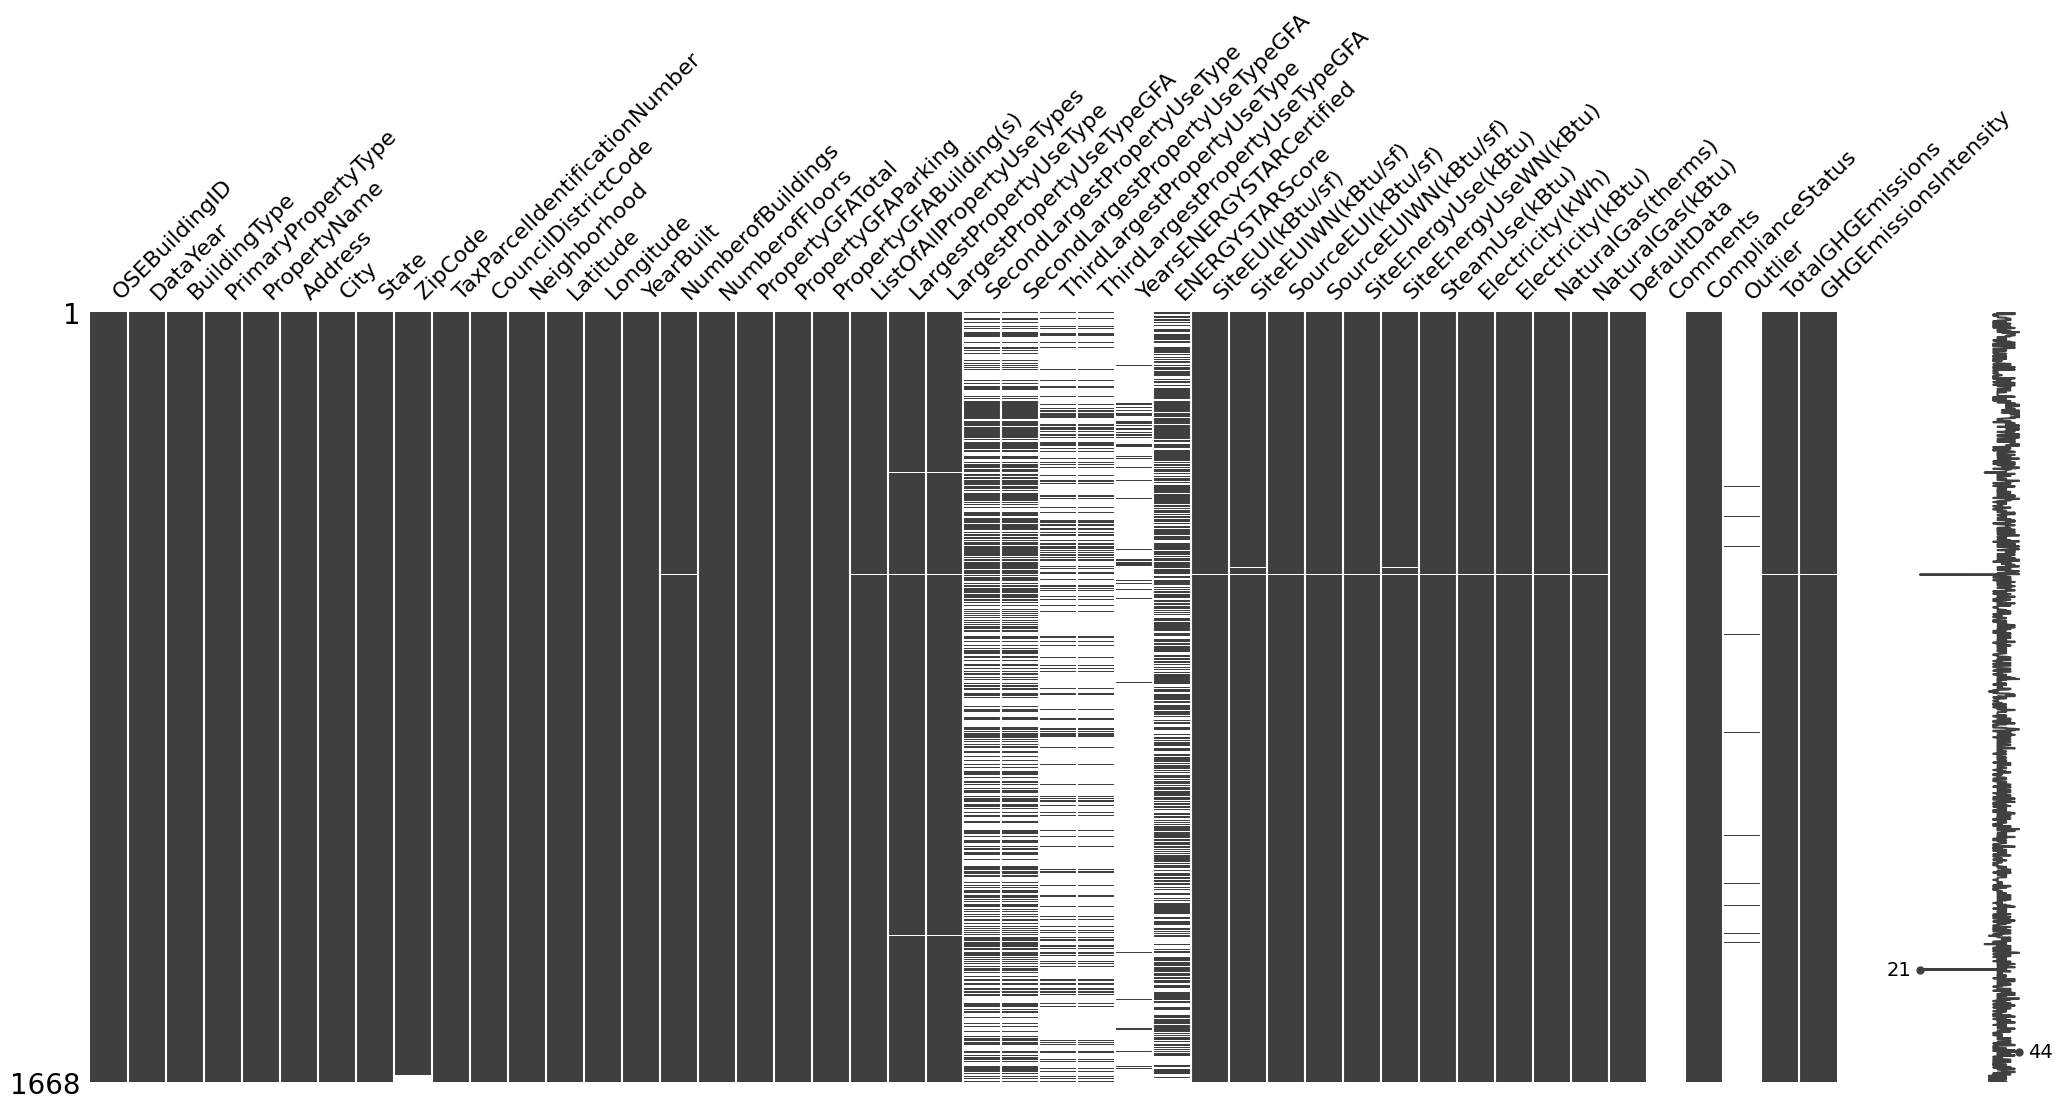

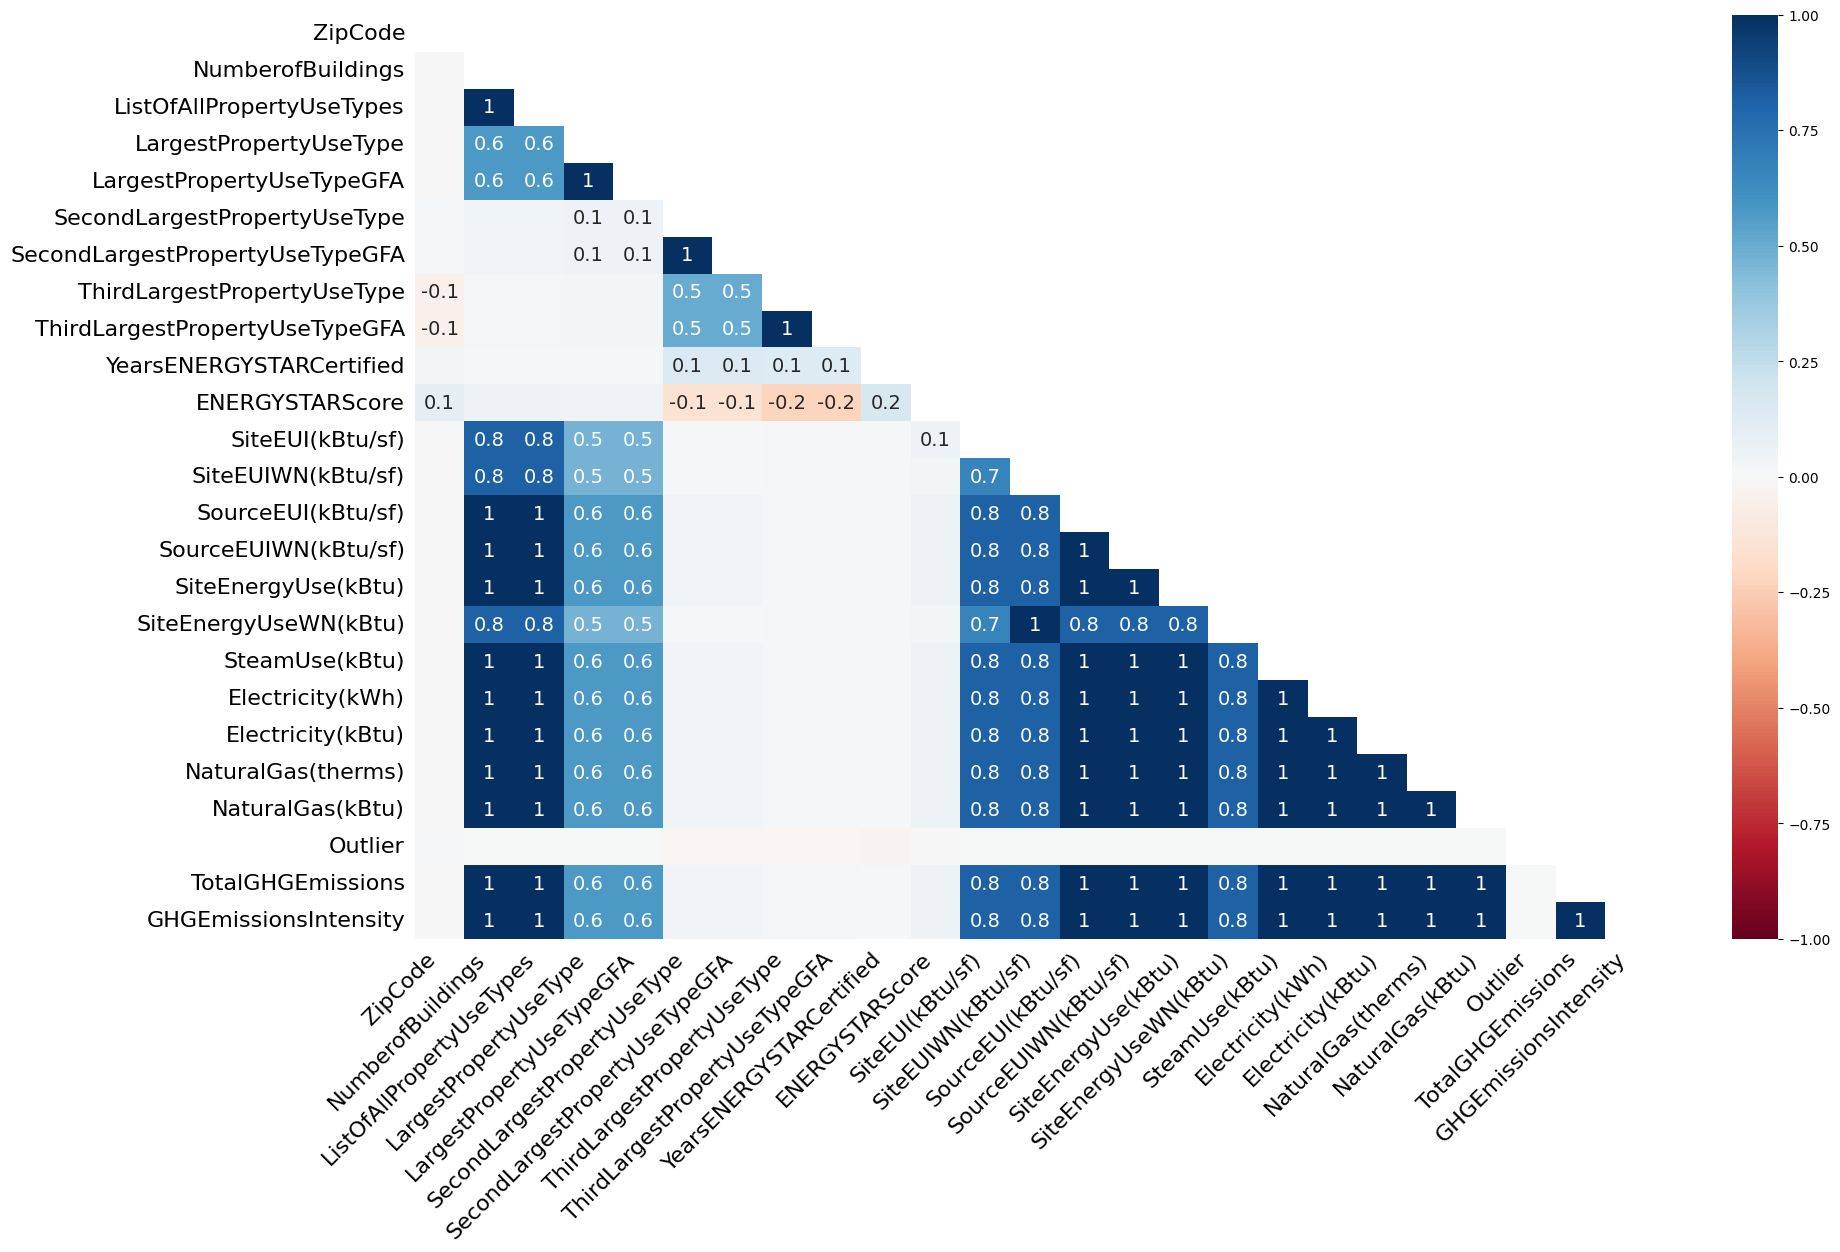

In [10]:
# On visualise le nouveau dataset afin de constater la qualité du remplissage et les correlations entre colonnes
msno.matrix(df_NonResidential)
msno.heatmap(df_NonResidential)

Les colones d'usages secondaires révèlent de nombreuses valeurs manquantes.  
Ce qui explique aussi les correlations faibles sur ces colonnes.

Ces colones seront retraitées dans les features car elles impactent la consomation d'energie on ne peut pas créer de moyenne car ce sont des valeurs qualitative. 

Elle seront probablement retraitées en booleen ou modelisées en forest.

#### 6) Filtrage avec les colonnes utilitaires métier dećlarées
On se sert des colonnes utilitaires pour améliorer le dataset
- 'DefaultData'
- 'ComplianceStatus'
- 'OutLier'


In [11]:
# 'DefaultData'
# On identifie le contenu des colonnes
for column in ['DefaultData','ComplianceStatus', 'Outlier']:
    print (f"-" * 50)
    print(df_NonResidential[column].value_counts())

--------------------------------------------------
DefaultData
False    1580
True       88
Name: count, dtype: int64
--------------------------------------------------
ComplianceStatus
Compliant                       1548
Error - Correct Default Data      88
Non-Compliant                     18
Missing Data                      14
Name: count, dtype: int64
--------------------------------------------------
Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64


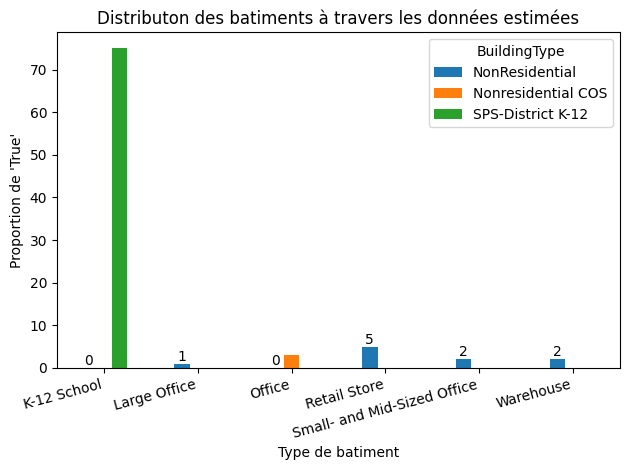

In [12]:
# On observe la repartition des données éstimées parmi les structures et fonctionsdes batiments, pour constater si il y a, ou non, concentration.
# On instancie le regroupement des batiments sur les données éstimées.
distri_dd = (
    df_NonResidential[df_NonResidential['DefaultData']== 1]
    .groupby(['PrimaryPropertyType','BuildingType'])['DefaultData']
    .count())

# Diagramme en barre
ax = distri_dd.unstack().plot(kind = 'bar')
ax.bar_label(ax.containers[0])

plt.title("Distributon des batiments à travers les données estimées")
plt.xlabel("Type de batiment")
plt.ylabel("Proportion de 'True'")
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.show()

In [13]:
df_NonResidential['BuildingType'].value_counts()

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

In [14]:
estimated_sps_total = (df_NonResidential[df_NonResidential['BuildingType'] == 'SPS-District K-12']['DefaultData'].mean() * 100).round(1)
print(f"La part des bâtiments scolaires dans les données éstimées est de : {estimated_sps_total} %")

La part des bâtiments scolaires dans les données éstimées est de : 76.5 %


La part des batiments scolaires est trop importantes pour pouvoir supprimer les entrées éstimées.  
Cela veut dire que si on elimine les données estimées du dataset, on supprimmera **76.5%** des bâtiments scolaires.   
Par conséquent, **la décision est de tout garder**. Cette décision est aussi appuyée par les résultats marginaux des autres types de bâtiments.

In [15]:
# 'ComplianceStatus'
(df_NonResidential['ComplianceStatus'].value_counts(normalize = True)*100).round(1)

ComplianceStatus
Compliant                       92.8
Error - Correct Default Data     5.3
Non-Compliant                    1.1
Missing Data                     0.8
Name: proportion, dtype: float64

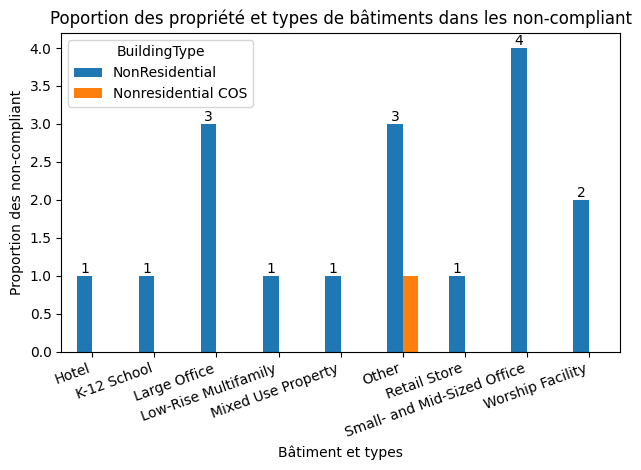

In [16]:
# On regroupe les types avec la condition non-compliant
distri_nc = (df_NonResidential[df_NonResidential['ComplianceStatus'] == 'Non-Compliant']
.groupby(['PrimaryPropertyType', 'BuildingType'])['ComplianceStatus']
.count())

ax = distri_nc.unstack().plot(kind = 'bar')
ax.bar_label(ax.containers[0])

plt.title('Poportion des propriété et types de bâtiments dans les non-compliant')
plt.xlabel('Bâtiment et types')
plt.ylabel('Proportion des non-compliant')
plt.xticks(rotation = 20, ha = 'right')
plt.tight_layout()
plt.show()


In [17]:
# On revoit la proportion des non-compliant sur les types de de structure et fonction.
proportion_building = (df_NonResidential
    .groupby('PrimaryPropertyType')
    .apply(lambda x : (x['ComplianceStatus'] == 'Non-Compliant')
    .mean() * 100).round(1)
    .sort_values(ascending = False)
)

display(proportion_building)

PrimaryPropertyType
Low-Rise Multifamily           33.3
Worship Facility                2.8
Large Office                    1.7
Other                           1.6
Small- and Mid-Sized Office     1.4
Hotel                           1.3
Retail Store                    1.1
Mixed Use Property              0.9
K-12 School                     0.7
Distribution Center             0.0
Laboratory                      0.0
Hospital                        0.0
Office                          0.0
Medical Office                  0.0
Restaurant                      0.0
Residence Hall                  0.0
Refrigerated Warehouse          0.0
Self-Storage Facility           0.0
Senior Care Community           0.0
Supermarket / Grocery Store     0.0
University                      0.0
Warehouse                       0.0
dtype: float64

On constate que le nombre de *'compliant'* renvoie **92.8 %**.   
Cela indique que presque la totalité des renseignements ont été conforméments fournis par les structures.  
Les **5.3%** renvoie des erreurs alimentant la colonne DefaultData par des valeurs éstimées.
Les 'Non-Compliant'sont repartis de facon homogène, son total est marginal.   
**Il n'est pas necessaire d'aller plus loin et de filtrer via cette colonne.**

In [18]:
# Les outliers
df_NonResidential['Outlier'].value_counts()

Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64

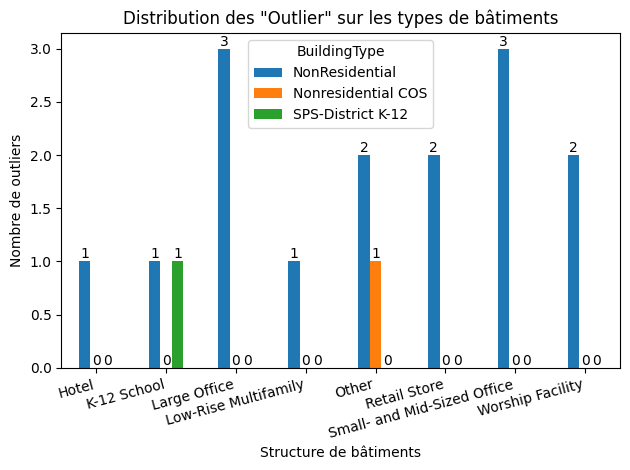

In [19]:
# On affiche l'histogramme des structures de batiments et de fonctions avec la condition outlier
outlier = (df_NonResidential[df_NonResidential['Outlier'].notna()]
    .groupby(['PrimaryPropertyType', 'BuildingType'])['Outlier']
    .count()
    )

ax = outlier.unstack().fillna(0).plot(kind = 'bar')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution des "Outlier" sur les types de bâtiments')
plt.xlabel('Structure de bâtiments')
plt.ylabel('Nombre de outliers')
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.show()


Les outliers sont peu nombreux et distribués de manières hétérogènes dans le type  
*'NonResidential'*.  
Dès lors, les outliers sont négligeables, **il est préferable de les retirer afin d'améliorer la précision des modèles futurs.**

#### 7) Recherhe les outliers non déclarés 
À l'aide de diagramme 'box' on observe les valeurs extêmes et on definie une stratégie pour les features.

/home/mohamed/Formation/Data Engineer/Projet 06 Anticipez les besoins de consomation de batiments/p6-ml-seattle-co2-energy-prediction/.venv/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:846: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  labels = axis.get_majorticklabels() + axis.get_minorticklabels()


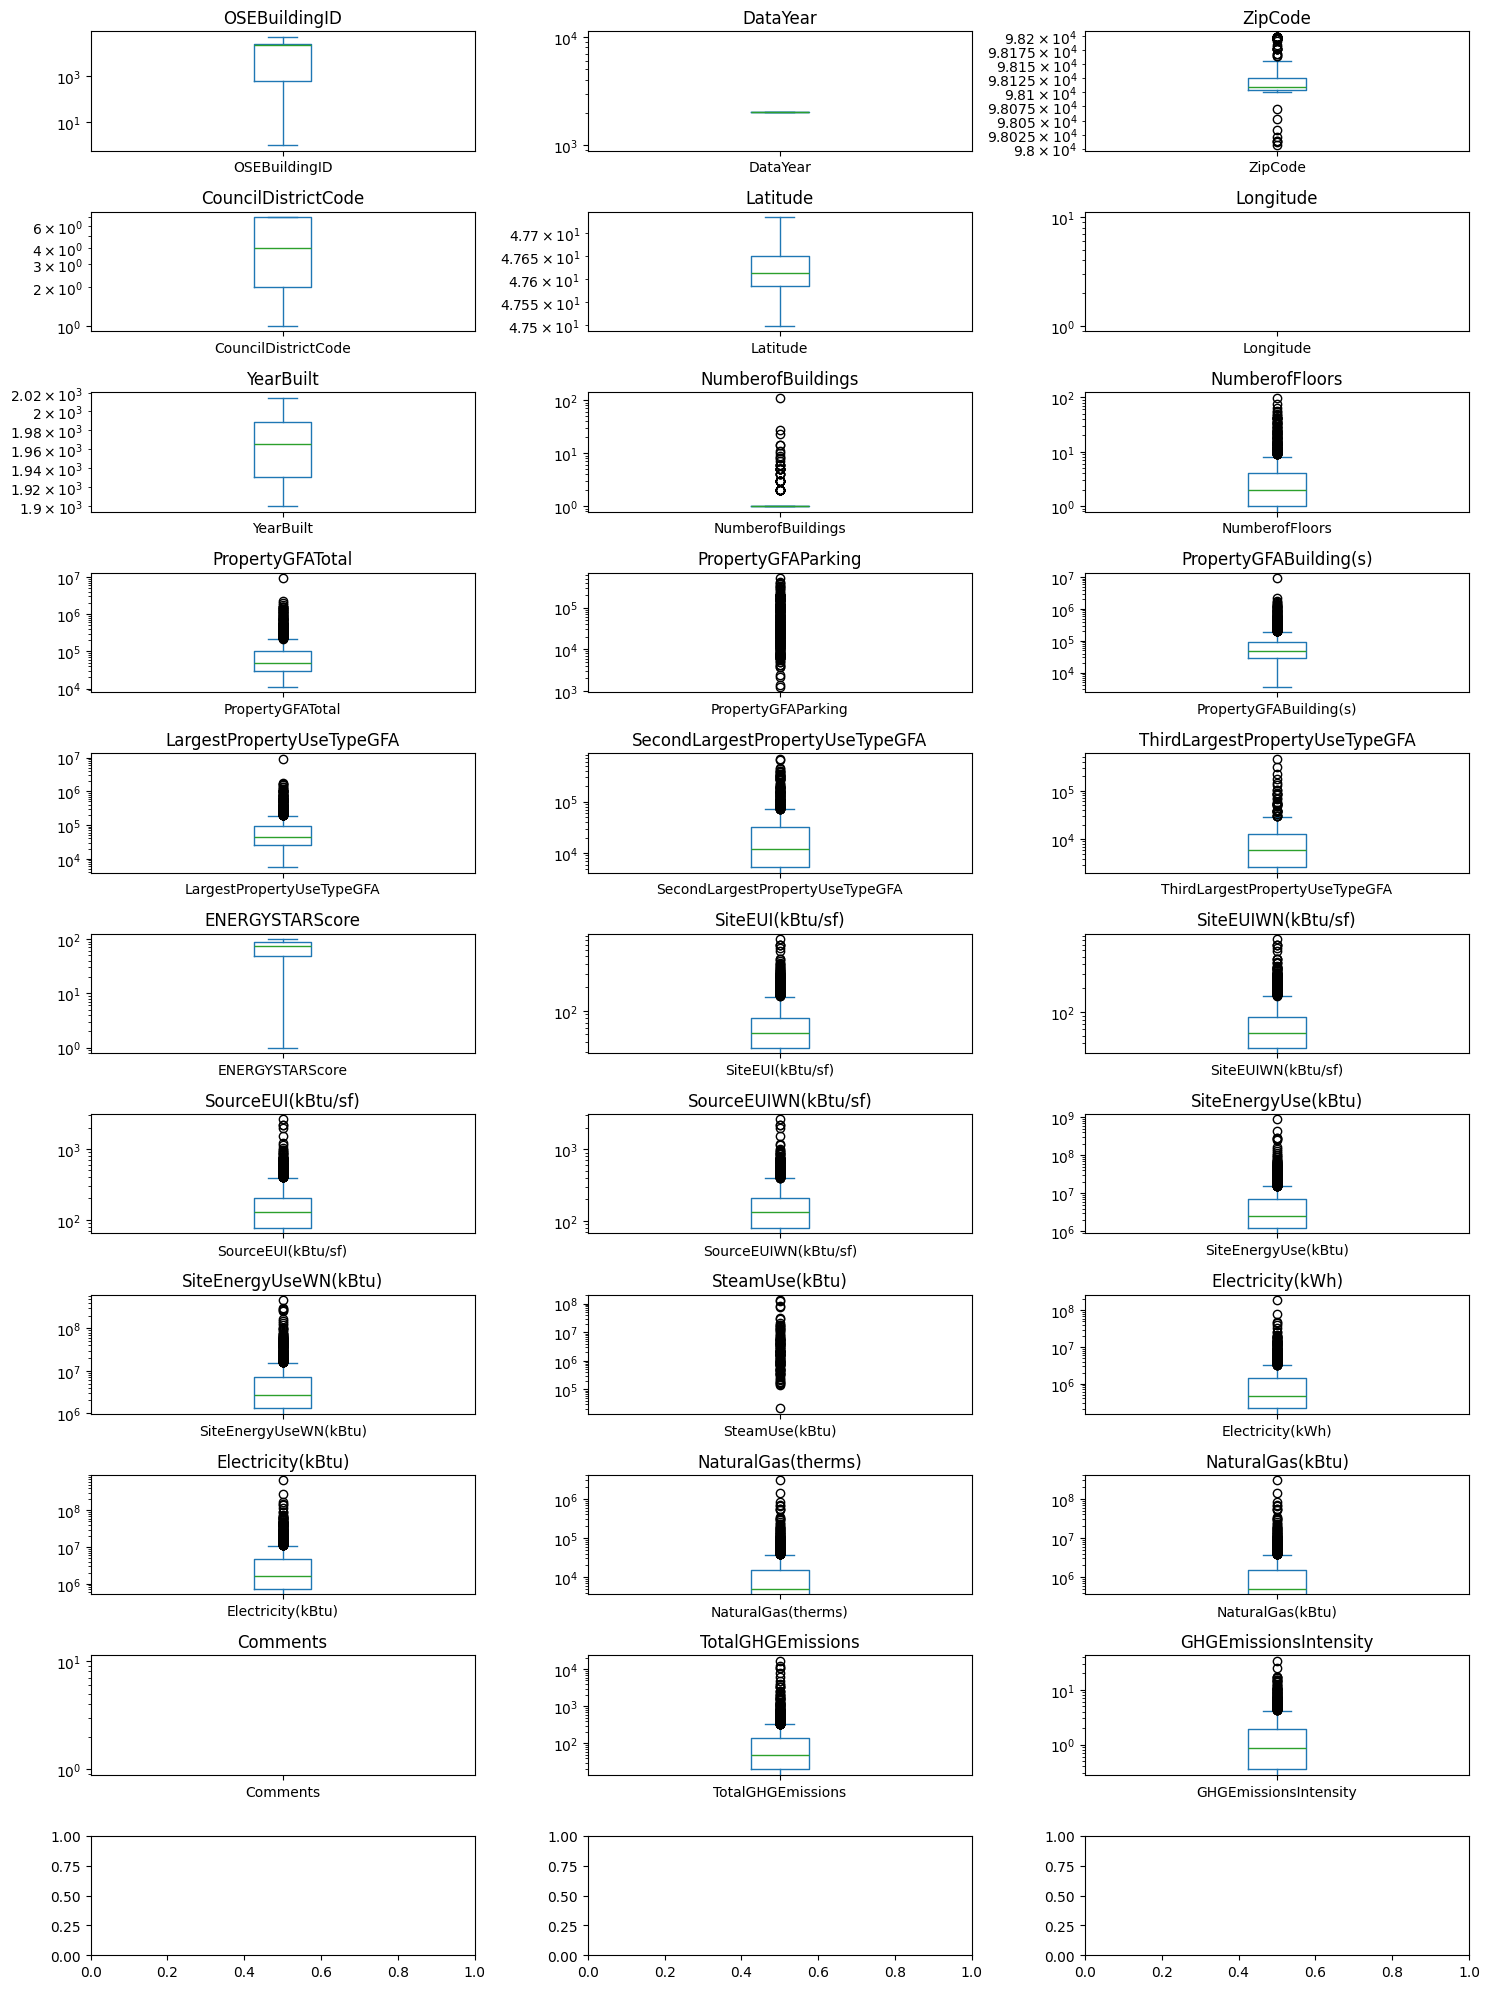

In [ ]:
col_num = df_NonResidential.select_dtypes(include = 'number').columns

fig, axes = plt.subplots(nrows=len(col_num)//3 + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(col_num):
    df_NonResidential[col].plot(kind='box', logy=True, ax=axes[i], title=col)

plt.tight_layout()
plt.show()

Il y a beaucoup de outliers notament dans les colonnes de benchs énergitiques et de surface, **ce qui est en fait totalement normal, car leurs variétés sont réelles.**  

*Attention aussi, parmi les colonnes, certaines categorielles sont presque binaire (BumberOfBuildings, NumberOfFloors, etc...), mecaniquement si une categorie domine, les autres apparaitont comme abbérantes sur des boxplots.*  

De plus, pour la modélisation, les colonnes à données énergetiques seront supprimées, pour eviter tout data leakage, lors de l'étape de préparation des features.

#### 8) Corrélation du dataset avec la target
L'objectif est de preselectionner les colonnes pour le feature engineering. Cette table de corrélation révelera déjà les appointances avec les targets pour la modélisation.

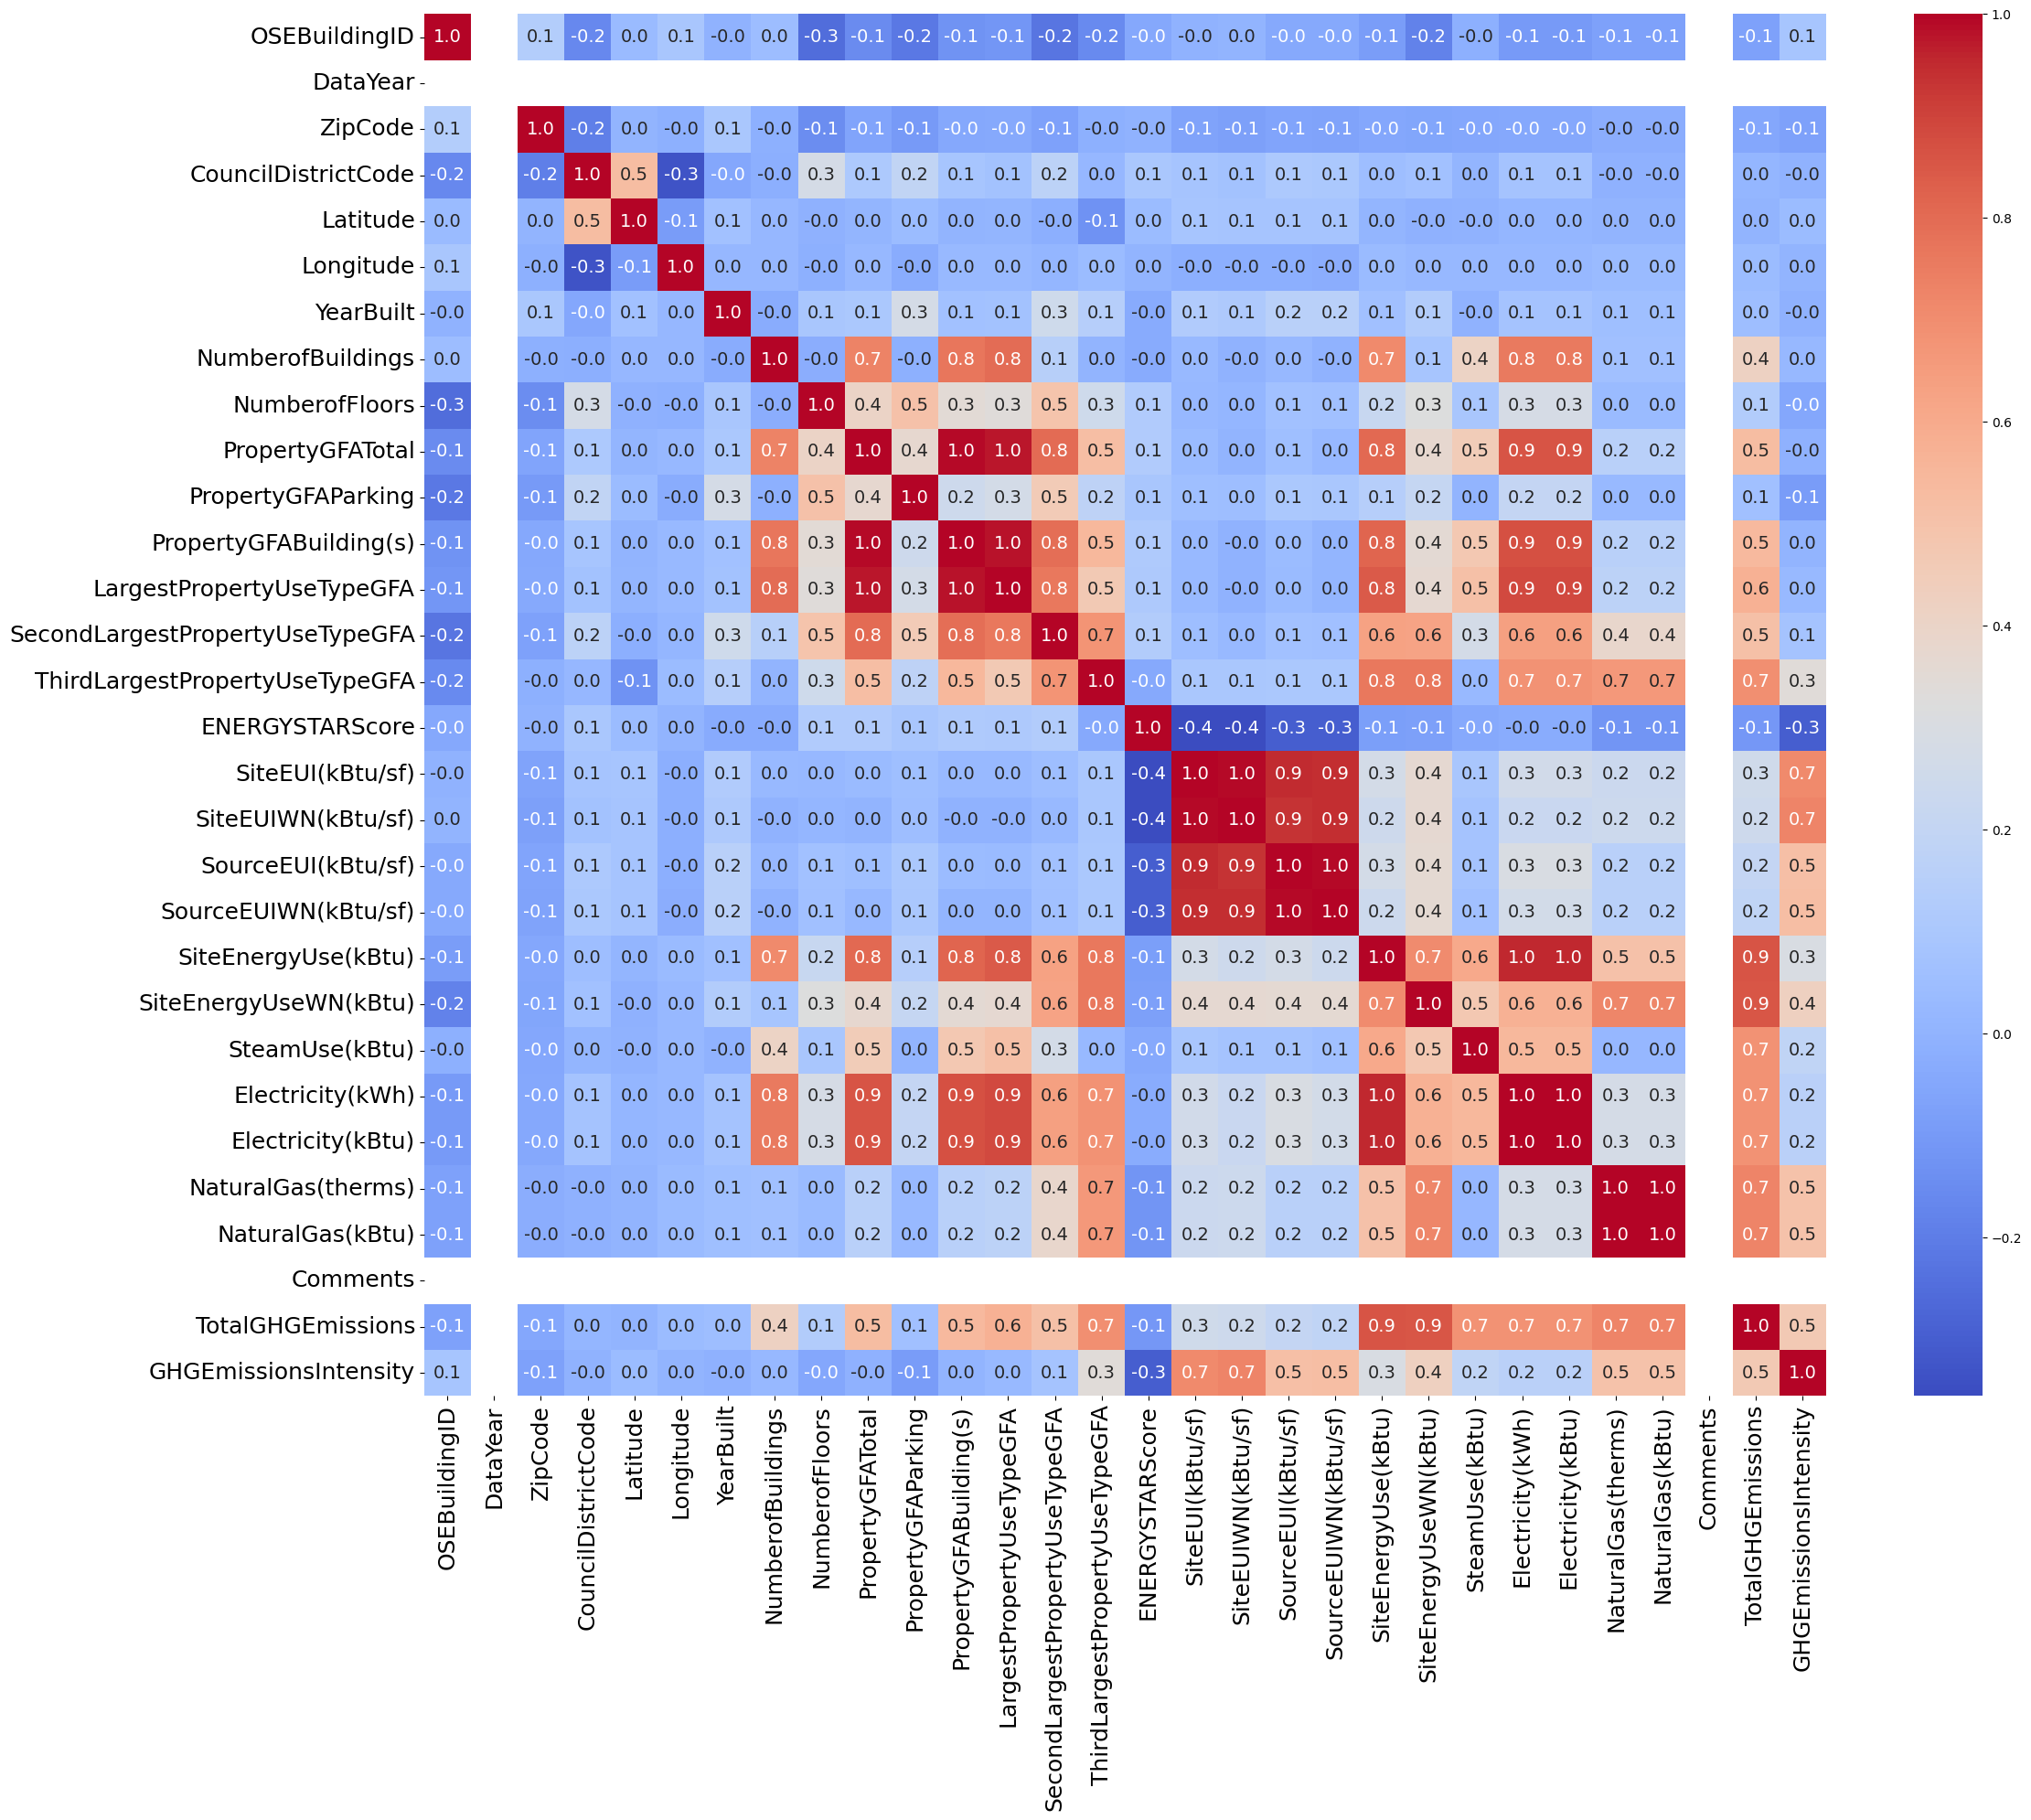

In [24]:
# Affichage d'une heatmap pour identifier une correlation des differentes colonnes avec les targets
col_num = df_NonResidential.select_dtypes(include = 'number').columns

plt.figure(figsize=(24,20))

sns.heatmap(df_NonResidential[col_num].corr(method = 'pearson'), annot = True, fmt = '.1f', cmap = 'coolwarm', annot_kws={"size": 14})

plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.tight_layout()
plt.show()


En conclusion, on constate quelque corrélation claire avc les 2 targets de la modelisation.  
Pour la target concernant l'émission de Co2 :  
- Nombre de bâtiments
- La surface totale 
- La surface des batiments
- Les usages secondaire et tertiaire (ici, plus étonnant par contre...)

Ces mêmes colonnes se correlent aussi entre elles. Lors de la preparation nous verrons si elles génèrent de la redondance, sinon les ratios viendront affuter la lecture du modele.
  
Pour la target energie, nous avons les mêmes colonnes, mais les correlations sont plus fortes.  
Nous garderons donc toutes ces colonnes pour le feature engineering.
Liste pour le nuage de points
number of building
propertygfatotal
propoertygfabuilding
prime
largest propertyusetye gfa
second gfa third


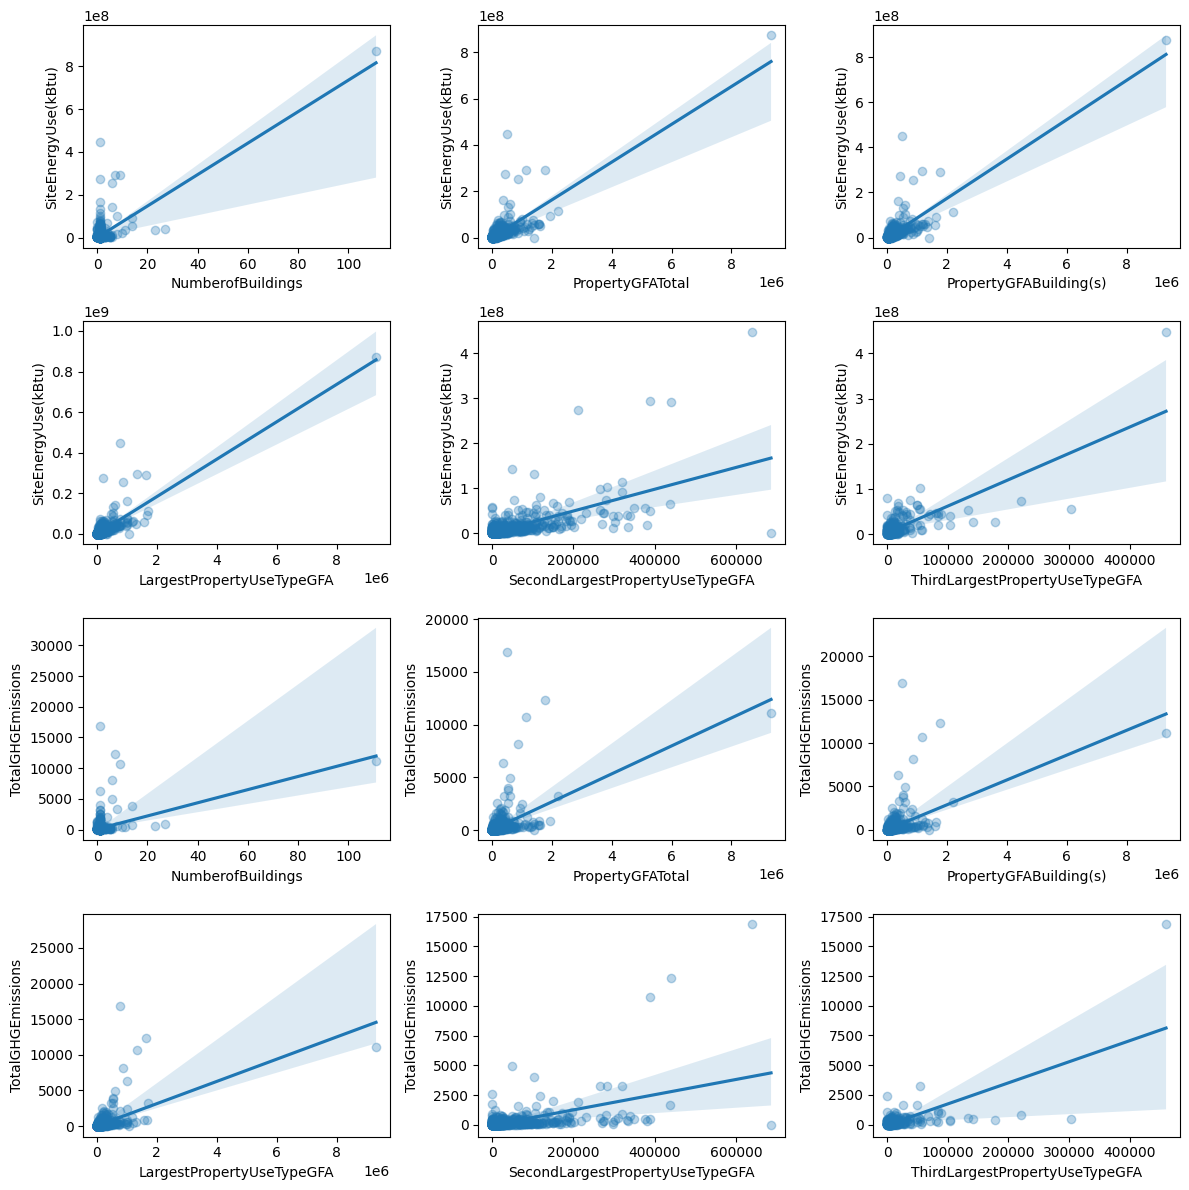

In [22]:
# Nuage de points
scatter_feats = [
    'NumberofBuildings',
    'PropertyGFATotal',
    'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
    'TotalGHGEmissions'
]

x_vars = scatter_feats[:-2]

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(x_vars):
    sns.regplot(data=df_NonResidential, x=col, y='SiteEnergyUse(kBtu)', 
                ax=axes[i], scatter_kws={'alpha': 0.3})
    
    sns.regplot(data=df_NonResidential, x=col, y='TotalGHGEmissions', 
                ax=axes[i+6], scatter_kws={'alpha': 0.3})

plt.tight_layout()
plt.show()




Entre les 2 targets preselectionnées. On constate deux choses :
- La première est que les corelations des 2 targets entre les features semble correspondre.
- La seconde et que l'intervale de confiance des variables semble plus élevé(spectre de la droite reduit) sur la target de comsomation energetique.
- En conclusion il n'est pas nécessaire de retenir les 2 targets, car elles se corrèlent entre elles, mais uniquement la target de conso énergetique qui a le R2 le plus élevé.

In [23]:
print(f"Avant: {len(data)}, Après: {len(df_NonResidential)}, Supprimées: {len(data) - len(df_NonResidential)}") 

Avant: 3376, Après: 1668, Supprimées: 1708


#### FIN EDA: On garder ce df (df_NonResidential) il sera preparer dans la prochaine étape de feature engineering
1. Supression des colonnes inutiles
2. Transformation des colonnes categorielle en numeriques
3. Creation de 8 nouvelles features
   - ratio_batiment = PropertyGFABuilding(s) / PropertyGFATotal → proportion réellement bâtie
   - ratio_parking = PropertyGFAParking / PropertyGFATotal → proportion parking, consomme éclairage et chaleur
   - surface_espaces_verts = PropertyGFATotal - PropertyGFAParking - PropertyGFABuilding(s) → surface non bâtie non capturée par les autres colonnes
   - has_secondary_use, has_third_use → booléens indiquant si un usage secondaire/tertiaire existe, évite d'imputer 50-70% de NaN
   - nb_types_energie → nombre de types d'énergie utilisés, indicateur de complexité énergétique4. 
  La target retenue est la consomation energetique.